In [26]:
import scipy.io.wavfile as wav
from scipy.signal import find_peaks

In [35]:
rate, data = wav.read('sound_data/A-flute.wav')
trimmed_data = data[:44100]  # Keep first 1 second
wav.write('A-flute_1.wav', 44100, trimmed_data)

In [36]:
rate, data = wav.read('A-flute_1.wav')
print(data.shape)

(44100, 2)


In [37]:
duration_seconds = len(data) / 44100
print(f"Duration: {duration_seconds} seconds")

Duration: 1.0 seconds


## LOOP TO TRIM

In [2]:
import os

folder_path = 'sound_data'
os.makedirs('./trimmed_files')

for filename in os.listdir(folder_path):
    if filename.endswith('.wav'):
        file_path = os.path.join(folder_path, filename)
        sample_rate, data = wav.read(file_path)
        trimmed_data = data[:44100]  # Slice the data array to the first second
        trimmed_filename = f"1_{filename}"
        trimmed_file_path = os.path.join('./trimmed_files', trimmed_filename)
        wav.write(trimmed_file_path, sample_rate, trimmed_data)

        print(f"Trimmed {filename} and saved as {trimmed_filename}")

FileExistsError: [WinError 183] Cannot create a file when that file already exists: './trimmed_files'

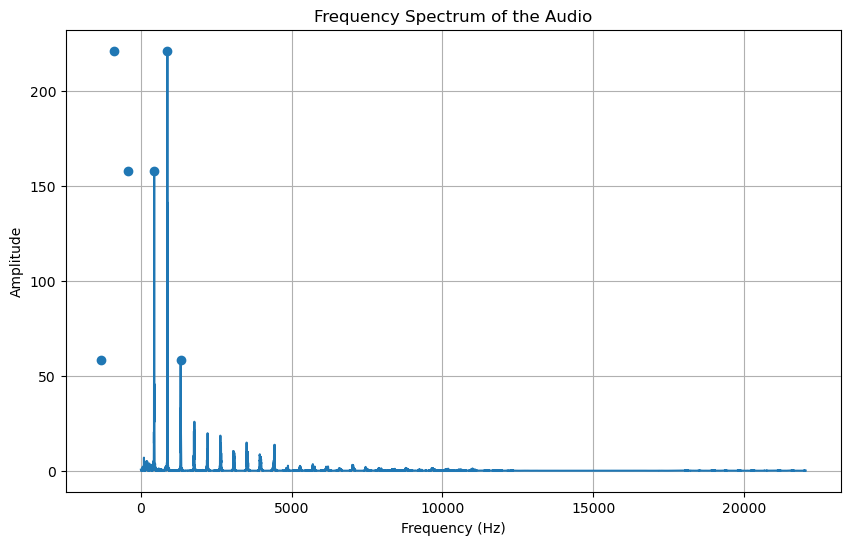

In [46]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate, data = wav.read('trimmed_files/1_A-Violoncello.wav')

# isolate channel 1
data = data[:, 0]

# FFT audio signal (time-domain data)
fft_data = np.fft.fft(data)

# amplitude spectrum (positive values)
amplitude = np.abs(fft_data)

# corresponding frequencies
n = len(data)
frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # Frequency axis

# Plot frequency spectrum
plt.figure(figsize=(10, 6))

#plt.plot(frequencies[::n//2], amplitude[:n//2])
peak_indices, _ = find_peaks(amplitude, height=50,distance=50)

plt.scatter(frequencies[peak_indices],amplitude[peak_indices])

plt.plot(frequencies[:n // 2], amplitude[:n // 2])  # Only plot positive frequencies
plt.title('Frequency Spectrum of the Audio')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
#plt.ylim(0,10)
plt.grid(True)
plt.show()

#timbre? freq near it or multiples that determine timbre
#normalise to main tone, 440 fundamental, 
#diff notes amplitude: nnormalise by dividing by the amplitude of the main peak of the note freq ie. 440

In [45]:
fft_data

array([-0.56729937+0.j        , -0.29276899+0.32966527j,
       -0.02884112+0.18580961j, ..., -0.09164798-0.19458653j,
       -0.02884112-0.18580961j, -0.29276899-0.32966527j],
      shape=(44100,), dtype=complex64)

In [97]:
# Step 5: Find the index of the peak frequency (maximum amplitude)
positive_frequencies = frequencies[:len(frequencies)//2]
positive_amplitude = amplitude[:len(amplitude)//2]

peak_index = np.argmax(positive_amplitude)  # Find the index of max amplitude
peak_frequency = positive_frequencies[peak_index]  # Get the corresponding frequency

# Print the peak frequency
print(f"Peak frequency: {peak_frequency} Hz")

Peak frequency: 878.0 Hz


In [34]:
find_peaks(amplitude, height=50,distance=50) #arbitrary... prominence=scipyguide on how to determine hehe 0, 10, 100 formula..., but no height might change if volume.
#justify whyyy: we tried 10 noumbers this gave best results, but ocnsistent.

(array([  441,   878,  1319, 42781, 43222, 43659]),
 {'peak_heights': array([158.00149536, 221.14759827,  58.28505707,  58.28505707,
         221.14759827, 158.00149536])})

In [12]:
print(frequencies[:10])
len(frequencies)
print(frequencies[10:])
frequencies>=0
np.all(frequencies[:n//2] > 0)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[10. 11. 12. ... -3. -2. -1.]


np.False_

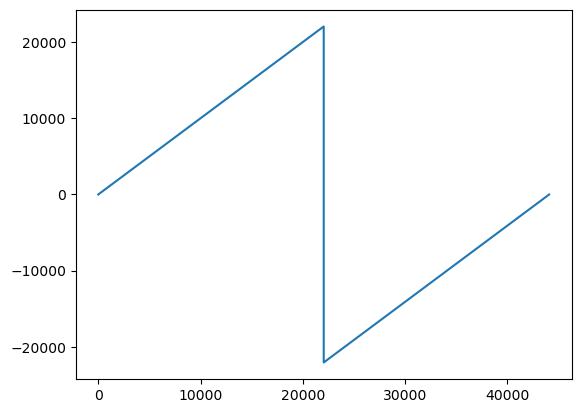

In [15]:
plt.plot(frequencies)

In [33]:
print('identified peaks are', frequencies[peak_indices])
find_peaks(frequencies)

identified peaks are [  441.   878.  1319. -1319.  -878.  -441.]


(array([22049]), {})

AttributeError: module 'numpy' has no attribute 'j'

In [41]:
np.abs(1+1j)

np.float64(1.4142135623730951)

In [42]:
np.sqrt(2)

np.float64(1.4142135623730951)

np.complex128(1j)